In [10]:
import os

pfad = "/Users/sascha0404/Documents/UNI/Chemie/5. Semester/PR Instrumentalanalytisches Praktikum/AAS"

if os.path.exists(pfad):
    print("Ordner existiert ✅")
else:
    print("Ordner existiert NICHT ❌")

import os

ordner = "/Users/sascha0404/Documents/UNI/Chemie/5. Semester/PR Instrumentalanalytisches Praktikum/AAS"
datei = "Daten AAS.xlsx"  # hier steht der Name, den du gefunden hast

pfad = os.path.join(ordner, datei)

print(pfad)



Ordner existiert ✅
/Users/sascha0404/Documents/UNI/Chemie/5. Semester/PR Instrumentalanalytisches Praktikum/AAS/Daten AAS.xlsx


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import os

ordner = "/Users/sascha0404/Documents/UNI/Chemie/5. Semester/PR Instrumentalanalytisches Praktikum/AAS"
datei = "Daten AAS.xlsx"   # ggf. anpassen
pfad = os.path.join(ordner, datei)

df = pd.read_excel(pfad)

# DIREKT Spalten 0 und 1 nehmen
x = df.iloc[:, 0]   # erste Spalte = Probe
y = df.iloc[:, 1]   # zweite Spalte = Abs.

plt.figure()
plt.scatter(x, y)
plt.xlabel("Probe")
plt.ylabel("Absorption")
plt.title("AAS Messwerte")
plt.grid(True)
plt.show()

IndexError: single positional indexer is out-of-bounds

In [13]:
import pandas as pd
import os

ordner = "/Users/sascha0404/Documents/UNI/Chemie/5. Semester/PR Instrumentalanalytisches Praktikum/AAS"
datei = "Daten AAS.xlsx"   # exakt so wie die Datei heißt!
pfad = os.path.join(ordner, datei)

df = pd.read_excel(pfad)

print("Form der Tabelle:", df.shape)
print(df.head())

Form der Tabelle: (0, 0)
Empty DataFrame
Columns: []
Index: []


Gefundene Sheets: ['Tabelle1']
Sheet 'Tabelle1' Form: (17, 2)
Verwende Sheet: Tabelle1
x-Werte (Probe):
2     1
3     1
4     1
5     2
6     2
7     2
8     3
9     3
10    3
11    4
12    4
13    4
14    5
15    5
16    5
Name: 0, dtype: int64
y-Werte (Absorption):
2     0.1077
3     0.1083
4     0.1088
5     0.1631
6     0.1655
7     0.1657
8     0.2424
9     0.2442
10    0.2462
11    0.3398
12    0.3378
13    0.3362
14    0.4104
15    0.4061
16    0.4097
Name: 1, dtype: float64


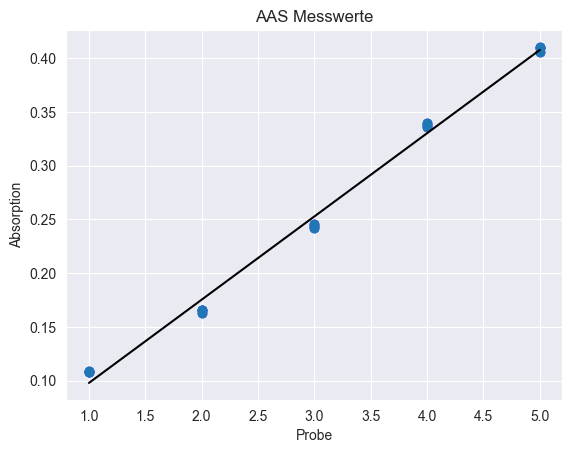

Regressionsgleichung:
y = 0.077410 * x + 0.020563


In [23]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Pfad und Dateiname anpassen, falls nötig
ordner = "/Users/sascha0404/Documents/UNI/Chemie/5. Semester/PR Instrumentalanalytisches Praktikum/AAS"
datei = "Daten AAS.xlsx"   # exakt so, wie die Datei heißt
pfad = os.path.join(ordner, datei)

# Alle Tabellenblätter anschauen
xls = pd.ExcelFile(pfad)
print("Gefundene Sheets:", xls.sheet_names)

df = None

# Wir suchen das erste Sheet, das wirklich Daten enthält
for sheet in xls.sheet_names:
    tmp = pd.read_excel(pfad, sheet_name=sheet, header=None)
    print(f"Sheet '{sheet}' Form:", tmp.shape)
    if tmp.shape[0] > 0 and tmp.shape[1] >= 2:  # mind. 1 Zeile, 2 Spalten
        df = tmp
        print("Verwende Sheet:", sheet)
        break

if df is None:
    print("Keine Daten in den Tabellenblättern gefunden.")
else:
    # Annahme: Zeile 1 ist leer, Zeile 2 enthält Überschriften,
    # ab Zeile 3 (Index 2) stehen deine Messwerte.
    # -> wir nehmen die Zeilen ab Index 2
    roh_x = df.iloc[2:, 0]  # Spalte A = Probe
    roh_y = df.iloc[2:, 1]  # Spalte B = Abs.

    # In Zahlen umwandeln (Komma -> Punkt bei der Absorption)
    x = pd.to_numeric(roh_x, errors="coerce")
    y = pd.to_numeric(roh_y.astype(str).str.replace(",", "."), errors="coerce")

    # Zeilen mit NaN rauswerfen (falls irgendwo leer)
    maske = (~x.isna()) & (~y.isna())
    x = x[maske]
    y = y[maske]


# Lineare Regression berechnen: y = m*x + b
m, b = np.polyfit(x, y, 1)

# Gerade berechnen
y_gerade = m * x + b

print("x-Werte (Probe):")
print(x)
print("y-Werte (Absorption):")
print(y)

# Diagramm plotten
plt.figure()

plt.scatter(x, y, color="blue", label="Messwerte")
plt.plot(x, y_gerade, color="black", label=f"y = {m:.4f}·x + {b:.4f}")
plt.scatter(x, y)
plt.xlabel("Probe")
plt.ylabel("Absorption")
plt.title("AAS Messwerte")
plt.grid(True)
plt.show()

# Gerade auch als Text ausgeben
print("Regressionsgleichung:")
print(f"y = {m:.6f} * x + {b:.6f}")

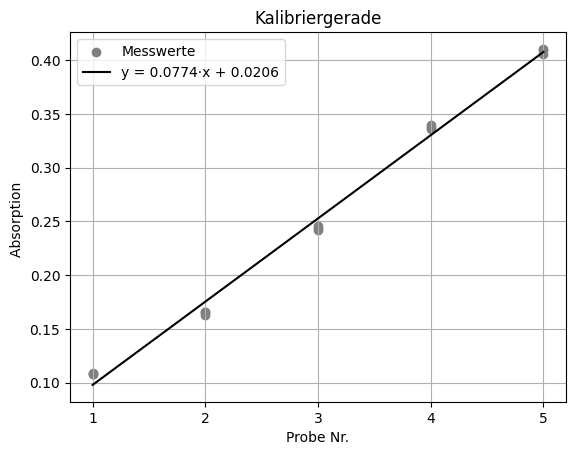

Regressionsgleichung:
y = 0.077410 * x + 0.020563
y_gerade = 2     0.097973
3     0.097973
4     0.097973
5     0.175383
6     0.175383
7     0.175383
8     0.252793
9     0.252793
10    0.252793
11    0.330203
12    0.330203
13    0.330203
14    0.407613
15    0.407613
16    0.407613
Name: 0, dtype: float64
s_y = 0.009141226703294564
Konzentration Messlösung c_mess = 0.2656418206088798 mg/L
Konzentration Probe c_Probe(Zink) = 53.12836412177596 mg/L
s_xmess = 0.6120245362609588
s_cProbe = 122.40490725219175
m_ZnSO4 = 66.61263671807636
s_mProbe =  153.4719 mg
t = 2.16
c_Probe = 53.1284 ± 264.3946 mg/L (n = 15; s_c = 122.40490725219175; P = 95%)
m_ZnSO4 =  66.6126 ± 331.4994 mg (n = 15; s_c = 122.40490725219175; P = 95%) 
------------------------------------------------------------
x_i = [0.  0.2 0.4 0.6 0.8]
x_bar = 0.4
b = 0.07741000000000002
n = 15


In [74]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Pfad und Datei
ordner = "/Users/sascha0404/Documents/UNI/Chemie/5. Semester/PR Instrumentalanalytisches Praktikum/AAS"
datei = "Daten AAS.xlsx"
pfad = os.path.join(ordner, datei)

sheet_name = "Tabelle1"

# Excel laden
df = pd.read_excel(pfad, sheet_name=sheet_name, header=None)

# Messwerte holen (ab Zeile 3)
roh_x = df.iloc[2:, 0]   # Konzentrationen / Probenstufen
roh_y = df.iloc[2:, 1]   # Abs.

# In Zahlen umwandeln
x = pd.to_numeric(roh_x, errors="coerce")
y = pd.to_numeric(roh_y.astype(str).str.replace(",", "."), errors="coerce")

# Leere Zeilen entfernen
maske = (~x.isna()) & (~y.isna())
x = x[maske]
y = y[maske]

# ------------------ Regression ------------------
b, a = np.polyfit(x, y, 1)      # m = Steigung, b = Achsenabschnitt
y_gerade = b * x + a            # ŷ (y-dach)

n = 15

# Standardabweichung der Regression s_y
z = np.sum((y - y_gerade)**2)
s_y = np.sqrt(z / (n - 2))

# ------------------ Messprobe ------------------

y_mess = 0.252793333   # Mittelwert der y- Werte

# Konzentration der Messlösung aus der Kalibriergeraden
# A = a + b*c  ->  c = (A - a)/b
c_mess =  a / b      # SKALAR

# Verdünnungsfaktor und Konzentration der ursprünglichen Probe
V_f = (100/5) * (50/5)
c_Probe = c_mess * V_f      # statt c_mess / (1 / V_f)

# ------------------ s_x nach deiner Formel ------------------
x_i = np.array([0.0, 0.2, 0.4, 0.6, 0.8])   # <- WICHTIG: Array!
x_bar = np.mean(x_i)
N = len(x_i)

s_xmess = (s_y / b) * np.sqrt(
    (1 / N) +
    (y_mess**2 / (b**2 * np.sum((x_i - x_bar)**2))))

s_x = (s_y / b) * np.sqrt(1/N + (y_bar**2) / (b**2 * np.sum((standards - x_bar)**2)))

s_cProbe = s_xmess * V_f

#Masse an ZnSO4 bestimmen
V_Probe = 0.5 #L
M_ZnSO4 = 161.44 #g/mol
M_Zn = 64.38 #g/mol
m_Zn = c_Probe * V_Probe

m_ZnSO4 = m_Zn * (M_ZnSO4/M_Zn)

#Wissenschaftliche Schreibweise c_Probe
# Freiheitsgrade (bei dir: Anzahl der Kalibrierpunkte)
nu = n - 2

# t-Wert für 95 % (typisch für n ≈ 5 → nu ≈ 3)
t = 2.160   # kannst du bei Bedarf aus der t-Tabelle anpassen

# erweiterte Unsicherheit
T_cProbe = t * s_cProbe

#Wissenschaftliche Schreibweise der Masse von ZnSO4
# Freiheitsgrade (bei dir: Anzahl der Kalibrierpunkte)
nu = n - 2


# erweiterte Unsicherheit
k = M_ZnSO4/M_Zn
s_mProbe = k * s_cProbe * V_Probe
T_mProbe = t * s_mProbe




# ------------------ Plot ------------------
plt.figure()
plt.scatter(x, y, color="grey", label="Messwerte")
plt.plot(x, y_gerade, color="black", label=f"y = {b:.4f}·x + {a:.4f}")
plt.xlabel("Probe Nr.")
plt.xticks(np.unique(x.astype(int)))
plt.ylabel("Absorption ")
plt.title("Kalibriergerade")
plt.legend()
plt.grid(True)
plt.show()

# ------------------ Ausgabe ------------------
print("Regressionsgleichung:")
print(f"y = {b:.6f} * x + {a:.6f}")
print("y_gerade =", y_gerade)
print("s_y =", s_y)
print(f"Konzentration Messlösung c_mess = {c_mess} mg/L")
print(f"Konzentration Probe c_Probe(Zink) = {c_Probe} mg/L")
print("s_xmess =", s_xmess)
print("s_cProbe =", s_cProbe)
print("m_ZnSO4 =", m_ZnSO4)
print(f"s_mProbe = {s_mProbe: .4f} mg")
print("t =", t)
print(f"c_Probe = {c_Probe:.4f} ± {T_cProbe:.4f} mg/L (n = {n}; s_c = {s_cProbe}; P = 95%)")
print(f"m_ZnSO4 = {m_ZnSO4: .4f} ± {T_mProbe:.4f} mg (n = {n}; s_c = {s_cProbe}; P = 95%) ")

print("-" * 60)

print("x_i =", x_i)
print("x_bar =", x_bar)
print("b =", b)
print("n =", n)

Masse Zinkoxid in der 500 mL Probe [mg]: 62.50 ± 7.78
y = 0.09797 + 0.38705x, R² = 0.9942
Reststandardabweichung (s_y): 0.01084
Konzentration bei y=0 (cMess) [mg/L]: 0.25313
Standardabweichung cMess (s_x) [mg/L]: 0.03151
Originalkonzentration der Probe [mg/L]: 50.62567
Standardabweichung Originalkonzentration [mg/L]: 6.30230
Masse Zinkoxid in Originalprobe [g]: 62.50389 ± 7.78100


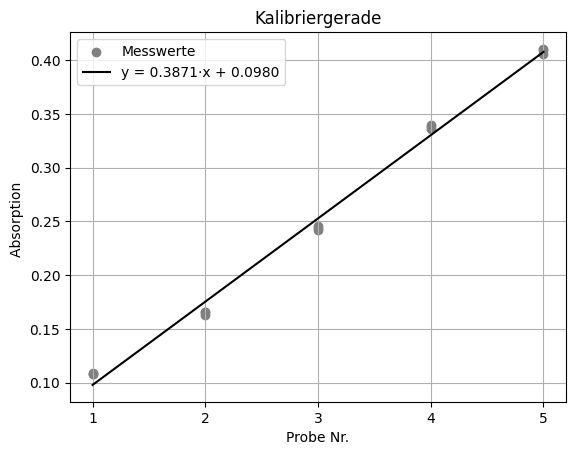

In [82]:
import numpy as np
import matplotlib.pyplot as plt

# Standardkonzentrationen für Standardaddition (mg/L)
standards = np.array([0, 0.2, 0.4, 0.6, 0.8])

# Absorptionen: jede Zeile = ein Standard, jede Spalte = Wiederholung
absorptionen = np.array([
    [0.1077, 0.1083, 0.1088],
    [0.1631, 0.1655, 0.1657],
    [0.2424, 0.2442, 0.2462],
    [0.3398, 0.3378, 0.3362],
    [0.4104, 0.4061, 0.4097]
])

# Mittelwerte und Standardabweichungen
mean_abs = absorptionen.mean(axis=1)
std_abs = absorptionen.std(axis=1, ddof=1)

# Lineare Regression (y = a + b*x)
b, a = np.polyfit(standards, mean_abs, 1)
fit_vals = a + b * standards

# R² berechnen
residuals = mean_abs - fit_vals
n = len(standards)
r_squared = 1 - np.sum(residuals**2)/np.sum((mean_abs - np.mean(mean_abs))**2)

# Reststandardabweichung (RSE)
s_y = np.sqrt(np.sum(residuals**2)/(n-2))

# Konzentration bei y=0 bestimmen
cMess = a / b

# Standardabweichung der Konzentration
x_bar = np.mean(standards)
y_bar = np.mean(mean_abs)
s_x = (s_y / b) * np.sqrt(1/n + (y_bar**2) / (b**2 * np.sum((standards - x_bar)**2)))

# Gesamtverdünnungsfaktor für Probe 1
Vf = (100/5) * (50/5)  # Verdünnung Probe * Verdünnung Standardaddition

# Originalkonzentration der Probe
c_original = cMess / (1/Vf)

# Unsicherheit auf die Originalkonzentration übertragen
s_c_original = s_x / (1/Vf)

# Volumen der Originalprobe
V_original = 0.500  # Liter

# Molmassen
M_ZnSO4 = 161.44  # g/mol
M_Zn = 65.38   # g/mol

# Absolute Masse Zinkoxid (mg)
m_ZnO = c_original * V_original * (M_ZnSO4 / M_Zn)      # mg/L * L -> mg
s_m_ZnO = s_c_original * V_original * (M_ZnSO4 / M_Zn)  # Unsicherheit

print(f"Masse Zinkoxid in der 500 mL Probe [mg]: {m_ZnO:.2f} ± {s_m_ZnO:.2f}")


# Ausgabe
print(f"y = {a:.5f} + {b:.5f}x, R² = {r_squared:.4f}")
print(f"Reststandardabweichung (s_y): {s_y:.5f}")
print(f"Konzentration bei y=0 (cMess) [mg/L]: {cMess:.5f}")
print(f"Standardabweichung cMess (s_x) [mg/L]: {s_x:.5f}")
print(f"Originalkonzentration der Probe [mg/L]: {c_original:.5f}")
print(f"Standardabweichung Originalkonzentration [mg/L]: {s_c_original:.5f}")
print(f"Masse Zinkoxid in Originalprobe [g]: {m_ZnO:.5f} ± {s_m_ZnO:.5f}")


plt.figure()
plt.scatter(x, y, color="grey", label="Messwerte")
plt.plot(x, y_gerade, color="black", label=f"y = {b:.4f}·x + {a:.4f}")
plt.xlabel("Probe Nr.")
plt.xticks(np.unique(x.astype(int)))
plt.ylabel("Absorption ")
plt.title("Kalibriergerade")
plt.legend()
plt.grid(True)
plt.show()


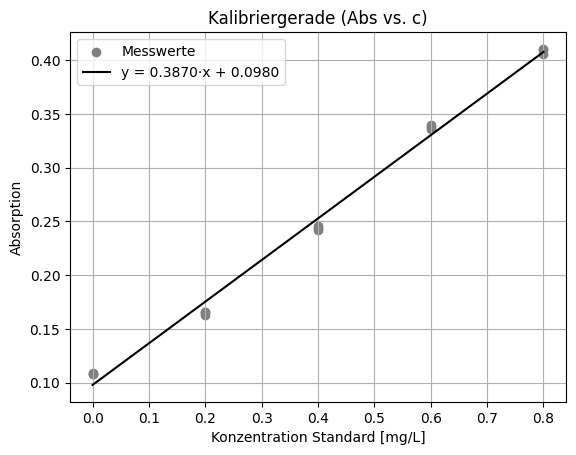

Regressionsgleichung:
y = 0.387050 * x + 0.097973
s_y = 0.009141226703294567
Konzentration Messlösung c_mess = 0.2531 mg/L
Konzentration Probe c_Probe(Zink) = 50.6257 mg/L
s_xmess = 0.026578471396368195
s_cProbe = 5.315694279273639
m_ZnSO4 = 63.4747485303192
s_mProbe =  6.6648 mg
t = 2.16
c_Probe = 50.6257 ± 11.4819 mg/L (n = 15; s_c = 5.315694279273639; P = 95%)
m_ZnSO4 =  63.4747 ± 14.3961 mg (n = 15; s_c = 6.664846881375709; P = 95%) 
m_Zn = 25.31283641217759
------------------------------------------------------------
x_i = [0.  0.2 0.4 0.6 0.8]
x_bar = 0.4
b = 0.38704999999999995
n (Kalibrierpunkte) = 15
N (Standards) = 5


In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Pfad und Datei
ordner = "/Users/sascha0404/Documents/UNI/Chemie/5. Semester/PR Instrumentalanalytisches Praktikum/AAS"
datei = "Daten AAS.xlsx"
pfad = os.path.join(ordner, datei)

sheet_name = "Tabelle1"

# Excel laden
df = pd.read_excel(pfad, sheet_name=sheet_name, header=None)

# ---- Kalibrierdaten holen: G5:G17 und H5:H17 ----
roh_x = df.iloc[2:19, 6]   # Zeilen 5–17, Spalte G (Konz. Standard)
roh_y = df.iloc[2:19, 7]   # Zeilen 5–17, Spalte H (Signalhöhe)

# In Zahlen umwandeln
x = pd.to_numeric(roh_x, errors="coerce")
y = pd.to_numeric(roh_y.astype(str).str.replace(",", "."), errors="coerce")

# Leere Zeilen entfernen (falls unten noch was steht)
maske = (~x.isna()) & (~y.isna())
x = x[maske]
y = y[maske]

# ------------------ Regression ------------------
b, a = np.polyfit(x, y, 1)      # y = a + b*x
y_gerade = b * x + a
n = len(y)

z = np.sum((y - y_gerade)**2)
s_y = np.sqrt(z / (n - 2))

# ------------------ Messprobe ------------------
y_mess = 0.252793333   # Mittelwert der Proben-Absorption

# A = a + b*c  ->  c = (A - a)/b
c_mess = a / b

# Verdünnungsfaktor und Konzentration der ursprünglichen Probe
V_f = (100/5) * (50/5)   # so wie du es angesetzt hast
c_Probe = c_mess * V_f

# ------------------ s_x nach deiner Formel ------------------
# Kalibrierkonzentrationen (einmalig, ohne Wiederholungen)
x_i = np.array([0.0, 0.2, 0.4, 0.6, 0.8])
x_bar = np.mean(x_i)
N = len(x_i)  # = 5 Kalibrierstufen

s_xmess = (s_y / b) * np.sqrt(
    (1 / N) +
    (y_mess**2 / (b**2 * np.sum((x_i - x_bar)**2)))
)

s_cProbe = s_xmess * V_f

# Masse an ZnSO4 bestimmen
V_Probe = 0.5  # L (prüfen, ob das wirklich 500 mL sein sollen!)
M_ZnSO4 = 161.44 # g/mol
M_Zn = 64.38     # g/mol

m_Zn = c_Probe * V_Probe           # mg Zn
m_ZnSO4 = m_Zn * (M_ZnSO4/M_Zn)    # mg ZnSO4

# t-Wert für 95 %
nu = n - 2
t = 2.160

T_cProbe = t * s_cProbe

k = M_ZnSO4/M_Zn
s_mProbe = k * s_cProbe * V_Probe
T_mProbe = t * s_mProbe

#Berechnung Zink
m_Zn = m_ZnSO4 * (M_Zn/M_ZnSO4)

# ------------------ Plot ------------------
plt.figure()
plt.scatter(x, y, color="grey", label="Messwerte")
# Für eine glatte Gerade gerne sortierte x-Werte verwenden:
x_plot = np.linspace(x.min(), x.max(), 100)
y_plot = b * x_plot + a
plt.plot(x_plot, y_plot, color="black", label=f"y = {b:.4f}·x + {a:.4f}")

plt.xlabel("Konzentration Standard [mg/L]")
plt.ylabel("Absorption")
plt.title("Kalibriergerade (Abs vs. c)")
plt.legend()
plt.grid(True)
plt.show()

# ------------------ Ausgabe ------------------
print("Regressionsgleichung:")
print(f"y = {b:.6f} * x + {a:.6f}")
print("s_y =", s_y)
print(f"Konzentration Messlösung c_mess = {c_mess:.4f} mg/L")
print(f"Konzentration Probe c_Probe(Zink) = {c_Probe:.4f} mg/L")
print("s_xmess =", s_xmess)
print("s_cProbe =", s_cProbe)
print("m_ZnSO4 =", m_ZnSO4)
print(f"s_mProbe = {s_mProbe: .4f} mg")
print("t =", t)
print(f"c_Probe = {c_Probe:.4f} ± {T_cProbe:.4f} mg/L (n = {n}; s_c = {s_cProbe}; P = 95%)")
print(f"m_ZnSO4 = {m_ZnSO4: .4f} ± {T_mProbe:.4f} mg (n = {n}; s_c = {s_mProbe}; P = 95%) ")
print("m_Zn =", m_Zn)
print("-" * 60)
print("x_i =", x_i)
print("x_bar =", x_bar)
print("b =", b)
print("n (Kalibrierpunkte) =", n)
print("N (Standards) =", N)
